In [2]:
import pandas as pd
import numpy as np 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dropout,
    Flatten,
    Dense
)

In [3]:
df = pd.read_csv("fashion-mnist_test.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# 1
X = df.drop('label', axis=1)


X = X / 255.0 # Normalize pixel values to range [0, 1]
y = df['label']

X = np.array(X) # Convert to NumPy arrays
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 10 normalized pixel values:")
print(X[0][:10])

Shape of X: (10000, 784)
Shape of y: (10000,)

First 10 normalized pixel values:
[0.         0.         0.         0.         0.         0.
 0.         0.03529412 0.03137255 0.        ]


In [5]:
# 2 
X = df.drop("label", axis=1).values
y = df["label"].values
X = X / 255.0
y = to_categorical(y) # convert one-hot encoder
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,))) # relu convert output 0 to X 
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax')) # softmax multiclas clscifaction problem  

C:\Users\hetal\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [8]:
history = model.fit( X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7098 - loss: 0.8267 - val_accuracy: 0.8037 - val_loss: 0.5754
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8045 - loss: 0.5439 - val_accuracy: 0.8156 - val_loss: 0.5152
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8388 - loss: 0.4681 - val_accuracy: 0.8231 - val_loss: 0.4948
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8434 - loss: 0.4338 - val_accuracy: 0.8388 - val_loss: 0.4761
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8608 - loss: 0.3971 - val_accuracy: 0.8462 - val_loss: 0.4554
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8702 - loss: 0.3628 - val_accuracy: 0.8594 - val_loss: 0.4139
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8755 - loss: 0.3410 - val_accuracy: 0.8519 - val_loss: 0.4680
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.3278 - val_accuracy: 0.

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8460 - loss: 0.4520

Test Accuracy: 0.8460000157356262


In [10]:
# 3 
import pandas as pd
import numpy as np
import tensorflow as tf


X = df.drop("label", axis=1).values
y = df["label"].values
X = X / 255.0

X = X.reshape(-1, 28, 28, 1) # change shap an array
y = to_categorical(y)  

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = Sequential()


model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1))) # scan image using cond2D 
model.add(MaxPooling2D(pool_size=(2,2))) # reduce image size
model.add(Dropout(0.25))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5)) # remove values 
model.add(Dense(10, activation='softmax'))



model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

Epoch 1/10


C:\Users\hetal\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6037 - loss: 1.0838 - val_accuracy: 0.7775 - val_loss: 0.6095
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7475 - loss: 0.6847 - val_accuracy: 0.8119 - val_loss: 0.5265
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7800 - loss: 0.5949 - val_accuracy: 0.8275 - val_loss: 0.4863
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7928 - loss: 0.5406 - val_accuracy: 0.8269 - val_loss: 0.4753
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8103 - loss: 0.5030 - val_accuracy: 0.8450 - val_loss: 0.4387
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8203 - loss: 0.4759 - val_accuracy: 0.8512 - val_loss: 0.4326
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8263 - loss: 0.4484 - val_accuracy: 0.8600 - val_loss: 0.4166
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8373 - loss: 0.4280 - val_accuracy: 0.8662 - val

In [11]:
# 4 
import matplotlib.pyplot as plt



X = df.drop("label", axis=1).values
y = df["label"].values
X = X / 255.0
X = X.reshape(-1, 28, 28, 1)



y = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = Sequential()


model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(64,(3,3),activation='relu'))


model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))


model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)


loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)




Epoch 1/10


C:\Users\hetal\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5950 - loss: 1.1004 - val_accuracy: 0.7500 - val_loss: 0.6399
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7478 - loss: 0.6848 - val_accuracy: 0.7912 - val_loss: 0.5541
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7794 - loss: 0.5926 - val_accuracy: 0.8238 - val_loss: 0.4943
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7967 - loss: 0.5428 - val_accuracy: 0.8487 - val_loss: 0.4478
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8073 - loss: 0.5148 - val_accuracy: 0.8569 - val_loss: 0.4242
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8217 - loss: 0.4794 - val_accuracy: 0.8519 - val_loss: 0.4214
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8316 - loss: 0.4509 - val_accuracy: 0.8813 - val_loss: 0.3865
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8373 - loss: 0.4277 - val_accuracy: 0.864

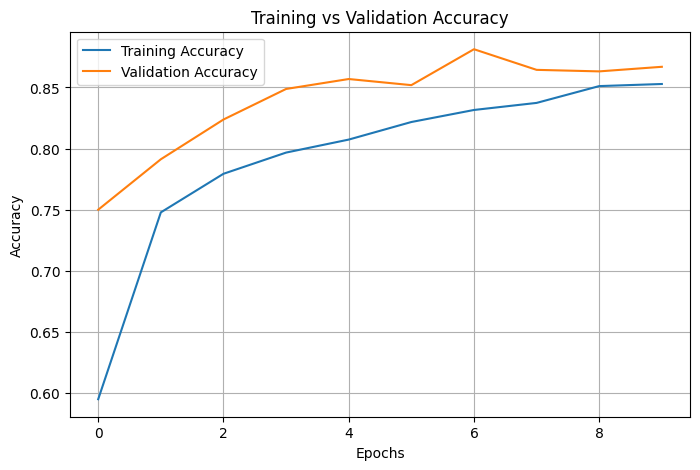

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()